--- Starting New Hive-Level Analysis ---
Step 1: Loading 'final_merged_dataset.csv'...
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/interim/Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data/final_merged_dataset.csv
Step 2: Pre-processing and Feature Engineering...
Dropped 187 rows with missing data (e.g., first inspections).
Using 1900 complete inspection records for modeling.

Step 3: Generating EDA plots...
Saved /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/eda_target_balance.png
Saved /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/eda_correlation_heatmap.png

Step 4: Splitting data and scaling features...
Training set size: 1520
Testing set size: 380

--- Training Model 1: Logistic Regression ---

Logistic Regression Results:
Accuracy: 0.758
Classification Report:
                 precision    recall  f1-score   support

Not Healthy (0)       0.81      0.79      0.80 

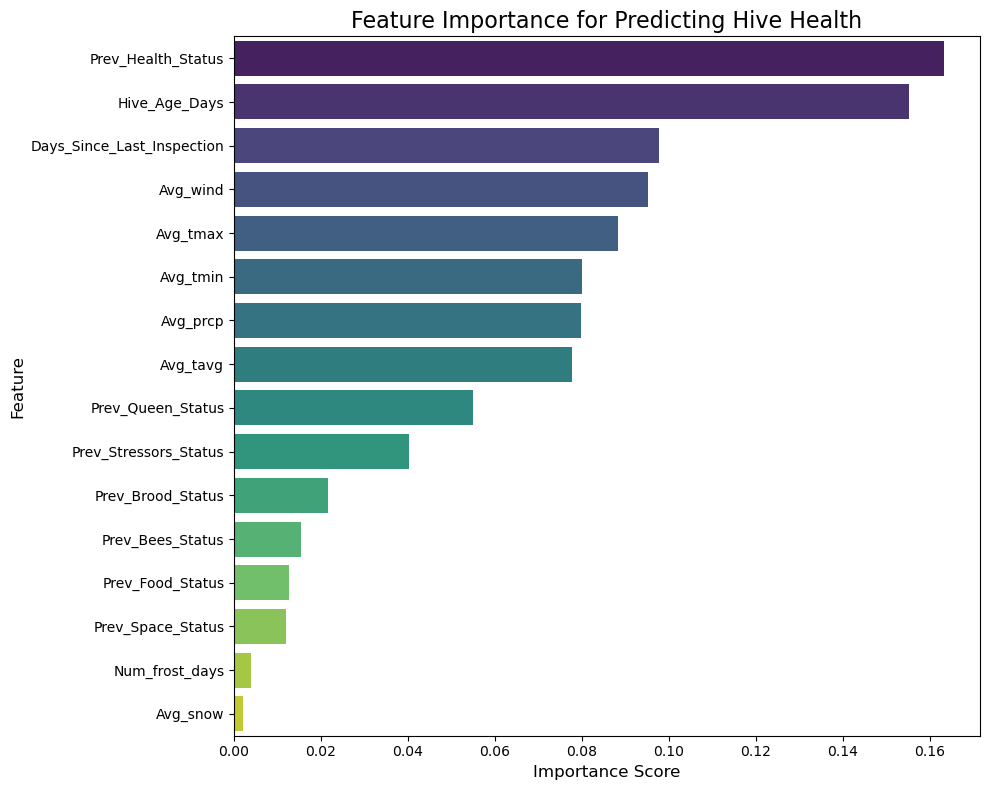


--- Analysis Complete ---


In [2]:
#!/usr/bin/env python3
"""
Hive-Level Health Classification (Notebook-safe)
- Loads final_merged_dataset.csv from common repo locations
- Encodes categorical prev-status features
- EDA: class balance and correlation heatmap (saved as PNGs)
- Models: Logistic Regression (with scaling) and Random Forest Classifier
- Prints accuracy and classification reports
"""

from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("--- Starting New Hive-Level Analysis ---")

# --- 1. Load Data ---
print("Step 1: Loading 'final_merged_dataset.csv'...")

def _detect_repo_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]  # type: ignore[name-defined]
    except NameError:
        pass
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / 'data').exists():
            return p
    return cwd

repo_root = _detect_repo_root()

# Try common locations
candidate_paths = [
    repo_root / 'data' / 'interim' / 'Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'processed' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'interim' / 'final_merged_dataset.csv',
    repo_root / 'final_merged_dataset.csv',
    Path.cwd() / 'final_merged_dataset.csv',
]

df = None
for p in candidate_paths:
    if p.exists():
        try:
            df = pd.read_csv(p)
            print(f"Loaded: {p}")
            break
        except Exception as e:
            print(f"Tried {p} but failed to read: {e}")

if df is None:
    print("Error: 'final_merged_dataset.csv' not found in expected locations.")
    print("Checked paths:")
    for p in candidate_paths:
        print(f" - {p}")
    print("Skipping analysis. Place the CSV in one of the paths above and re-run this cell.")
else:
    # --- 2. Pre-processing ---
    print("Step 2: Pre-processing and Feature Engineering...")

    # Target mapping: handle already-binary and Yes/No
    if 'Healthy' not in df.columns:
        raise KeyError("Required column 'Healthy' not found in dataset.")

    if df['Healthy'].dtype == 'O' or df['Healthy'].dtype.name == 'category':
        df['Healthy'] = df['Healthy'].map({'Yes': 1, 'No': 0})
    # If already numeric, coerce to 0/1 ints
    df['Healthy'] = pd.to_numeric(df['Healthy'], errors='coerce').astype('Int64')

    # Features list
    feature_cols = [
        'Days_Since_Last_Inspection',
        'Hive_Age_Days',
        'Prev_Brood_Status',
        'Prev_Bees_Status',
        'Prev_Queen_Status',
        'Prev_Food_Status',
        'Prev_Stressors_Status',
        'Prev_Space_Status',
        'Prev_Health_Status',
        'Avg_prcp',
        'Avg_wind',
        'Avg_tmax',
        'Avg_tmin',
        'Avg_tavg',
        'Avg_snow',
        'Num_frost_days',
    ]
    target_col = 'Healthy'

    # Auto-encode any categorical prev-status features to numeric codes
    cat_mappings: dict[str, dict] = {}
    for col in feature_cols:
        if col in df.columns and (df[col].dtype == 'O' or str(df[col].dtype).startswith('category')):
            codes, uniques = pd.factorize(df[col], sort=True)
            cat_mappings[col] = {str(u): int(i) for i, u in enumerate(uniques)}
            df[col] = codes

    # Drop rows where target or features are missing
    existing_feats = [c for c in feature_cols if c in df.columns]
    missing_feats = [c for c in feature_cols if c not in df.columns]
    if missing_feats:
        print(f"Warning: Missing expected feature columns (will be ignored): {missing_feats}")

    rows_before = len(df)
    df_clean = df.dropna(subset=existing_feats + [target_col])
    rows_after = len(df_clean)
    print(f"Dropped {rows_before - rows_after} rows with missing data (e.g., first inspections).")
    print(f"Using {rows_after} complete inspection records for modeling.")

    X = df_clean[existing_feats].copy()
    y = df_clean[target_col].astype(int)

    # --- 3. EDA (Exploratory Data Analysis) ---
    print("\nStep 3: Generating EDA plots...")
    out_dir = repo_root  # save figures at repo root for consistency

    # EDA 1: Target Balance
    plt.figure(figsize=(7, 5))
    sns.countplot(x=y)
    plt.title('Target Variable Balance (Healthy vs Not Healthy)', fontsize=14)
    plt.xticks(ticks=[0, 1], labels=['Not Healthy (0)', 'Healthy (1)'])
    plt.ylabel('Number of Inspections')
    plt.tight_layout()
    bal_path = out_dir / 'eda_target_balance.png'
    plt.savefig(bal_path)
    plt.close()
    print(f"Saved {bal_path}")

    # EDA 2: Correlation Heatmap (numeric only)
    plt.figure(figsize=(12, 8))
    corr_matrix = pd.concat([X, y.rename(target_col)], axis=1).corr(numeric_only=True)
    # Some columns might be constant -> drop NaNs
    corr_target = corr_matrix[[target_col]].dropna().sort_values(by=target_col, ascending=False)
    sns.heatmap(corr_target, annot=True, cmap='coolwarm', cbar=False, fmt='.2f')
    plt.title('Feature Correlation with Healthy Status', fontsize=14)
    plt.tight_layout()
    heat_path = out_dir / 'eda_correlation_heatmap.png'
    plt.savefig(heat_path)
    plt.close()
    print(f"Saved {heat_path}")

    # --- 4. Modeling ---
    print("\nStep 4: Splitting data and scaling features...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"Training set size: {len(X_train)}")
    print(f"Testing set size: {len(X_test)}")

    # --- Model 1: Logistic Regression ---
    print("\n--- Training Model 1: Logistic Regression ---")
    log_reg = LogisticRegression(random_state=42, max_iter=1000)
    log_reg.fit(X_train_scaled, y_train)
    y_pred_log = log_reg.predict(X_test_scaled)

    print("\nLogistic Regression Results:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.3f}")
    try:
        print("Classification Report:")
        print(classification_report(y_test, y_pred_log, target_names=['Not Healthy (0)', 'Healthy (1)']))
    except Exception:
        print(classification_report(y_test, y_pred_log))

    # --- Model 2: Random Forest Classifier ---
    print("\n--- Training Model 2: Random Forest Classifier ---")
    rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_clf.fit(X_train, y_train)
    y_pred_rf = rf_clf.predict(X_test)

    print("\nRandom Forest Results:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
    try:
        print("Classification Report:")
        print(classification_report(y_test, y_pred_rf, target_names=['Not Healthy (0)', 'Healthy (1)']))
    except Exception:
        print(classification_report(y_test, y_pred_rf))

    # --- 5. Feature Importance ---
    print("\nStep 5: Feature Importance (Random Forest)...")
    if hasattr(rf_clf, 'feature_importances_'):
        importances = rf_clf.feature_importances_
        importance_df = pd.DataFrame({'Feature': existing_feats, 'Importance': importances}).sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 8))
        sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
        plt.title('Feature Importance for Predicting Hive Health', fontsize=16)
        plt.xlabel('Importance Score', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()  # Show inline; not saving by default

    print("\n--- Analysis Complete ---")


=== Grouped experiment: group=Hive ID (maximize accuracy) ===
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/interim/Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data/final_merged_dataset.csv
Dropped 187 rows with missing numeric/group/target.
Using group column: HiveID
Train size: 1462, Test size: 438 (unique groups train=120)
Tuning Logistic Regression (group-aware CV)...
Best Logistic params: {'clf__C': 0.1, 'clf__penalty': 'l2'}, CV accuracy=0.771
Tuning Random Forest (group-aware CV)...
Best Logistic params: {'clf__C': 0.1, 'clf__penalty': 'l2'}, CV accuracy=0.771
Tuning Random Forest (group-aware CV)...
Best RF params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5}, CV accuracy=0.773

Logistic (best) Test Accuracy: 0.742
                 precision    recall  f1-score   support

Not Healthy (0)       0.80      0.81      0.80       288
    Healthy (1)       0.62      0.62      0.

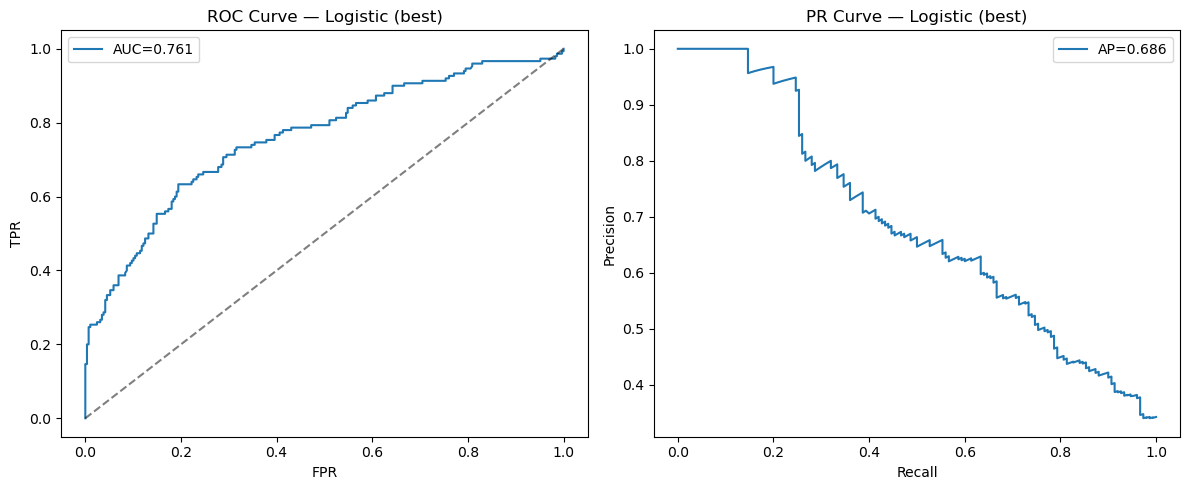


RandomForest (best) Test Accuracy: 0.772
                 precision    recall  f1-score   support

Not Healthy (0)       0.80      0.87      0.83       288
    Healthy (1)       0.70      0.59      0.64       150

       accuracy                           0.77       438
      macro avg       0.75      0.73      0.74       438
   weighted avg       0.77      0.77      0.77       438



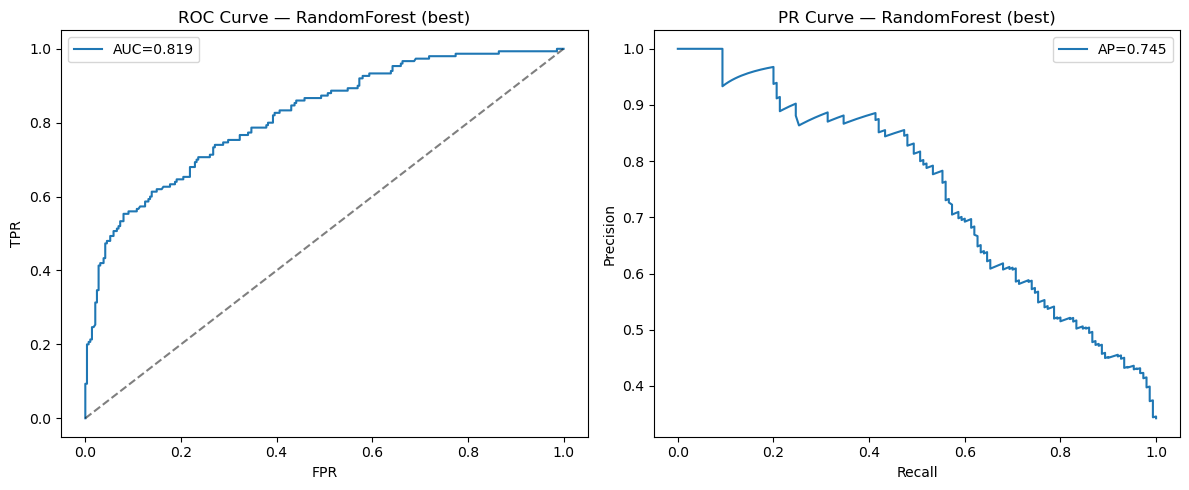


Winner on test (group=HiveID): RandomForest with accuracy=0.772


In [5]:
# Grouped, tuned classification with one-hot encoding (Hive ID)
# Goal: maximize accuracy with group-aware split and CV
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
)

print("=== Grouped experiment: group=Hive ID (maximize accuracy) ===")

# --- Utilities ---
def _detect_repo_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]  # type: ignore[name-defined]
    except NameError:
        pass
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / 'data').exists():
            return p
    return cwd

def _pick_group_col(df: pd.DataFrame, keywords: list[str]):
    cols = list(df.columns)
    for c in cols:
        lc = str(c).strip().lower()
        if any(k in lc for k in keywords):
            return c
    return None

repo_root = _detect_repo_root()

candidate_paths = [
    repo_root / 'data' / 'interim' / 'Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'processed' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'interim' / 'final_merged_dataset.csv',
    repo_root / 'final_merged_dataset.csv',
]

# --- Load ---
df = None
for p in candidate_paths:
    if p.exists():
        try:
            df = pd.read_csv(p)
            print(f"Loaded: {p}")
            break
        except Exception as e:
            print(f"Failed to read {p}: {e}")

if df is None:
    raise FileNotFoundError("final_merged_dataset.csv not found in expected locations.")

# --- Prepare target ---
if 'Healthy' not in df.columns:
    raise KeyError("Required column 'Healthy' not found.")
if df['Healthy'].dtype == 'O' or str(df['Healthy'].dtype).startswith('category'):
    df['Healthy'] = df['Healthy'].map({'Yes': 1, 'No': 0})
df['Healthy'] = pd.to_numeric(df['Healthy'], errors='coerce').astype('Int64')

# --- Feature sets ---
num_features = [
    'Days_Since_Last_Inspection',
    'Hive_Age_Days',
    'Avg_prcp', 'Avg_wind', 'Avg_tmax', 'Avg_tmin', 'Avg_tavg', 'Avg_snow', 'Num_frost_days'
]
cat_features = [
    'Prev_Brood_Status', 'Prev_Bees_Status', 'Prev_Queen_Status', 'Prev_Food_Status',
    'Prev_Stressors_Status', 'Prev_Space_Status', 'Prev_Health_Status'
]
all_expected = num_features + cat_features

missing = [c for c in all_expected if c not in df.columns]
if missing:
    print(f"Warning: missing expected columns (ignored): {missing}")

present_num = [c for c in num_features if c in df.columns]
present_cat = [c for c in cat_features if c in df.columns]

# group column: try common variants
group_col = _pick_group_col(df, ['hive_id', 'hive id', 'hive'])
if group_col is None:
    raise KeyError("Hive ID column not found (looked for keywords: 'hive_id', 'hive'). Available columns: " + ', '.join(df.columns.astype(str)))

# Keep necessary columns and drop NA
use_cols = present_num + present_cat + [group_col, 'Healthy']
df_use = df[use_cols].copy()
for c in present_num:
    df_use[c] = pd.to_numeric(df_use[c], errors='coerce')

before = len(df_use)
df_use = df_use.dropna(subset=present_num + [group_col, 'Healthy'])
# For categories, allow missing then treat as separate level via handle_unknown='ignore' + keep 'missing'
# Make sure categories are strings
for c in present_cat:
    df_use[c] = df_use[c].astype(str).fillna('Missing')

after = len(df_use)
print(f"Dropped {before - after} rows with missing numeric/group/target.")

X = df_use[present_num + present_cat]
y = df_use['Healthy'].astype(int)
groups = df_use[group_col].astype(str)

print(f"Using group column: {group_col}")

# --- Split (group-aware) ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
train_groups = groups.iloc[train_idx]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)} (unique groups train={train_groups.nunique()})")

# --- Preprocessor ---
preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', present_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), present_cat),
    ], remainder='drop'
)

# --- Models and grids (lean for speed) ---
log_pipe = Pipeline([
    ('prep', preprocess),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42))
])
log_grid = {
    'clf__C': [0.1, 1.0, 3.0],
    'clf__penalty': ['l2'],
}

rf_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
rf_grid = {
    'clf__max_depth': [None, 8],
    'clf__min_samples_leaf': [1, 5],
    'clf__max_features': ['sqrt'],
}

cv = GroupKFold(n_splits=5)

# --- Grid search with group-aware CV ---
print("Tuning Logistic Regression (group-aware CV)...")
log_gs = GridSearchCV(log_pipe, log_grid, scoring='accuracy', cv=cv, n_jobs=-1)
log_gs.fit(X_train, y_train, groups=train_groups)
print(f"Best Logistic params: {log_gs.best_params_}, CV accuracy={log_gs.best_score_:.3f}")

print("Tuning Random Forest (group-aware CV)...")
rf_gs = GridSearchCV(rf_pipe, rf_grid, scoring='accuracy', cv=cv, n_jobs=-1)
rf_gs.fit(X_train, y_train, groups=train_groups)
print(f"Best RF params: {rf_gs.best_params_}, CV accuracy={rf_gs.best_score_:.3f}")

# --- Evaluate on held-out test ---
def evaluate(model, name: str):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Test Accuracy: {acc:.3f}")
    try:
        print(classification_report(y_test, y_pred, target_names=['Not Healthy (0)', 'Healthy (1)']))
    except Exception:
        print(classification_report(y_test, y_pred))
    # Curves
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].plot(fpr, tpr, label=f'AUC={roc_auc:.3f}')
        axes[0].plot([0,1],[0,1],'k--',alpha=0.5)
        axes[0].set_title(f'ROC Curve — {name}')
        axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
        axes[1].plot(rec, prec, label=f'AP={ap:.3f}')
        axes[1].set_title(f'PR Curve — {name}')
        axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
        plt.tight_layout(); plt.show()
    return acc

log_test_acc = evaluate(log_gs.best_estimator_, 'Logistic (best)')
rf_test_acc = evaluate(rf_gs.best_estimator_, 'RandomForest (best)')

best_name = 'Logistic' if log_test_acc >= rf_test_acc else 'RandomForest'
print(f"\nWinner on test (group={group_col}): {best_name} with accuracy={max(log_test_acc, rf_test_acc):.3f}")


=== Grouped experiment: group=Apiary ID (maximize accuracy) ===
Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/interim/Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data/final_merged_dataset.csv
Using group column: ApiaryID
Train size: 1089, Test size: 811, unique ApiaryID in train: 8
Tuning Logistic Regression (group-aware CV)...
Best Logistic params: {'clf__C': 0.1, 'clf__penalty': 'l2'}, CV acc=0.751
Tuning Random Forest (group-aware CV)...
Best RF params: {'clf__max_depth': 8, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5}, CV acc=0.732

Logistic (best) Test Accuracy: 0.810
                 precision    recall  f1-score   support

Not Healthy (0)       0.85      0.83      0.84       494
    Healthy (1)       0.75      0.78      0.76       317

       accuracy                           0.81       811
      macro avg       0.80      0.80      0.80       811
   weighted avg       0.81      0.81      0.81    

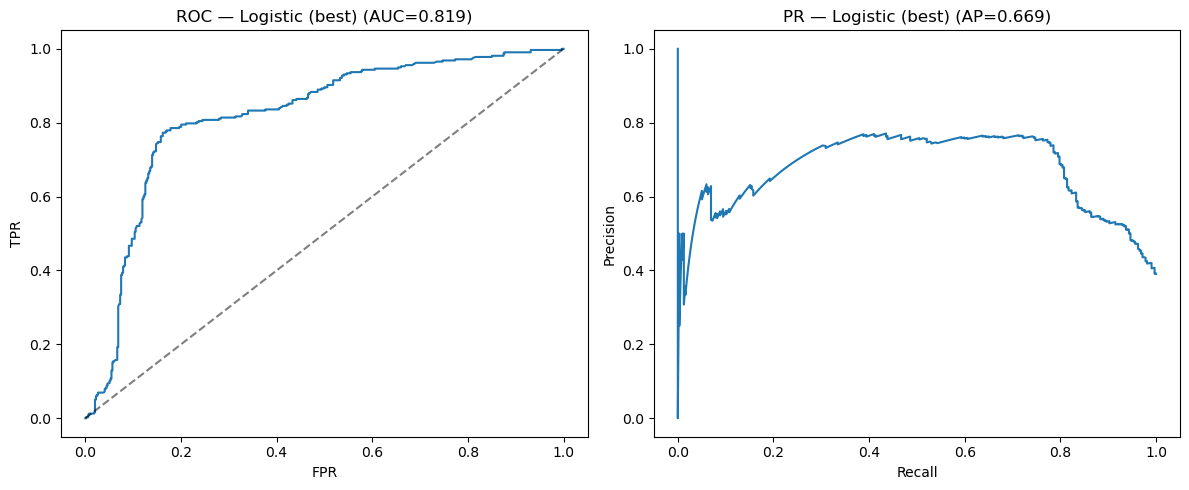


RandomForest (best) Test Accuracy: 0.772
                 precision    recall  f1-score   support

Not Healthy (0)       0.79      0.84      0.82       494
    Healthy (1)       0.73      0.66      0.69       317

       accuracy                           0.77       811
      macro avg       0.76      0.75      0.76       811
   weighted avg       0.77      0.77      0.77       811



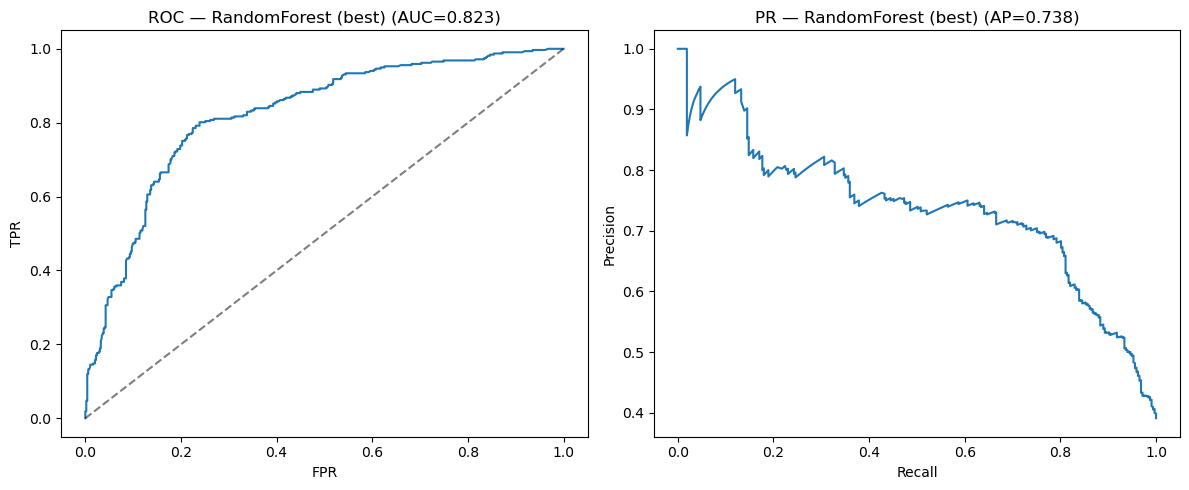


Winner on test (group=ApiaryID): Logistic with accuracy=0.810


In [6]:
# Re-run the grouped experiment using Apiary ID to compare performance
print("=== Grouped experiment: group=Apiary ID (maximize accuracy) ===")
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score,
)

# Helpers
def _detect_repo_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]  # type: ignore[name-defined]
    except NameError:
        pass
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / 'data').exists():
            return p
    return cwd

def _pick_group_col(df: pd.DataFrame, keywords: list[str]):
    for c in df.columns:
        lc = str(c).strip().lower()
        if any(k in lc for k in keywords):
            return c
    return None

repo_root = _detect_repo_root()

# Load dataset
candidate_paths = [
    repo_root / 'data' / 'interim' / 'Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'processed' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'interim' / 'final_merged_dataset.csv',
    repo_root / 'final_merged_dataset.csv',
]
df = None
for p in candidate_paths:
    if p.exists():
        try:
            df = pd.read_csv(p)
            print(f"Loaded: {p}")
            break
        except Exception as e:
            print(f"Failed to read {p}: {e}")
if df is None:
    raise FileNotFoundError("final_merged_dataset.csv not found in expected locations.")

# Target
if 'Healthy' not in df.columns:
    raise KeyError("Required column 'Healthy' not found.")
if df['Healthy'].dtype == 'O' or str(df['Healthy'].dtype).startswith('category'):
    df['Healthy'] = df['Healthy'].map({'Yes': 1, 'No': 0})
df['Healthy'] = pd.to_numeric(df['Healthy'], errors='coerce').astype('Int64')

# Features
num_features = [
    'Days_Since_Last_Inspection','Hive_Age_Days',
    'Avg_prcp','Avg_wind','Avg_tmax','Avg_tmin','Avg_tavg','Avg_snow','Num_frost_days'
]
cat_features = [
    'Prev_Brood_Status','Prev_Bees_Status','Prev_Queen_Status','Prev_Food_Status',
    'Prev_Stressors_Status','Prev_Space_Status','Prev_Health_Status'
]

present_num = [c for c in num_features if c in df.columns]
present_cat = [c for c in cat_features if c in df.columns]

# group column: try common variants
group_col = _pick_group_col(df, ['apiary_id', 'apiary id', 'apiary'])
if group_col is None:
    raise KeyError("Apiary ID column not found (looked for keywords: 'apiary_id', 'apiary'). Available columns: " + ', '.join(df.columns.astype(str)))

use_cols = present_num + present_cat + [group_col, 'Healthy']
df_use = df[use_cols].copy()
for c in present_num:
    df_use[c] = pd.to_numeric(df_use[c], errors='coerce')
for c in present_cat:
    df_use[c] = df_use[c].astype(str).fillna('Missing')

df_use = df_use.dropna(subset=present_num + [group_col, 'Healthy'])

X = df_use[present_num + present_cat]
y = df_use['Healthy'].astype(int)
groups = df_use[group_col].astype(str)

print(f"Using group column: {group_col}")

# Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
train_groups = groups.iloc[train_idx]
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}, unique {group_col} in train: {train_groups.nunique()}")

# Preprocess and models
preprocess = ColumnTransformer([
    ('num', 'passthrough', present_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), present_cat)
])

log_pipe = Pipeline([
    ('prep', preprocess),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42))
])
log_grid = {'clf__C': [0.1, 1.0, 3.0], 'clf__penalty': ['l2']}

rf_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
rf_grid = {'clf__max_depth': [None, 8], 'clf__min_samples_leaf': [1, 5], 'clf__max_features': ['sqrt']}

cv = GroupKFold(n_splits=5)

print("Tuning Logistic Regression (group-aware CV)...")
log_gs = GridSearchCV(log_pipe, log_grid, scoring='accuracy', cv=cv, n_jobs=-1)
log_gs.fit(X_train, y_train, groups=train_groups)
print(f"Best Logistic params: {log_gs.best_params_}, CV acc={log_gs.best_score_:.3f}")

print("Tuning Random Forest (group-aware CV)...")
rf_gs = GridSearchCV(rf_pipe, rf_grid, scoring='accuracy', cv=cv, n_jobs=-1)
rf_gs.fit(X_train, y_train, groups=train_groups)
print(f"Best RF params: {rf_gs.best_params_}, CV acc={rf_gs.best_score_:.3f}")


def evaluate(model, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Test Accuracy: {acc:.3f}")
    try:
        print(classification_report(y_test, y_pred, target_names=['Not Healthy (0)', 'Healthy (1)']))
    except Exception:
        print(classification_report(y_test, y_pred))
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        fig, axes = plt.subplots(1,2, figsize=(12,5))
        axes[0].plot(fpr, tpr)
        axes[0].plot([0,1],[0,1],'k--',alpha=0.5)
        axes[0].set_title(f'ROC — {name} (AUC={roc_auc_score(y_test, y_prob):.3f})')
        axes[1].plot(rec, prec)
        axes[1].set_title(f'PR — {name} (AP={average_precision_score(y_test, y_prob):.3f})')
        axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
        axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
        plt.tight_layout(); plt.show()
    return acc

log_acc = evaluate(log_gs.best_estimator_, 'Logistic (best)')
rf_acc = evaluate(rf_gs.best_estimator_, 'RandomForest (best)')
winner = 'Logistic' if log_acc >= rf_acc else 'RandomForest'
print(f"\nWinner on test (group={group_col}): {winner} with accuracy={max(log_acc, rf_acc):.3f}")


Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/interim/Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data/final_merged_dataset.csv

=== Grouping Summary ===
 Grouping Group_Column  Train_Size  Test_Size   Best_Model  Best_CV_Accuracy  Best_Test_Accuracy  Best_Test_ROC_AUC  Best_Test_AP                                                                       Best_Params
  Hive ID       HiveID        1462        438 RandomForest          0.772907            0.771689           0.818565      0.745460 {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5}
Apiary ID     ApiaryID        1089        811     Logistic          0.751139            0.810111           0.819040      0.669204                                             {'clf__C': 0.1, 'clf__penalty': 'l2'}

=== Grouping Summary ===
 Grouping Group_Column  Train_Size  Test_Size   Best_Model  Best_CV_Accuracy  Best_Test_Accuracy  Best_Test_ROC_A

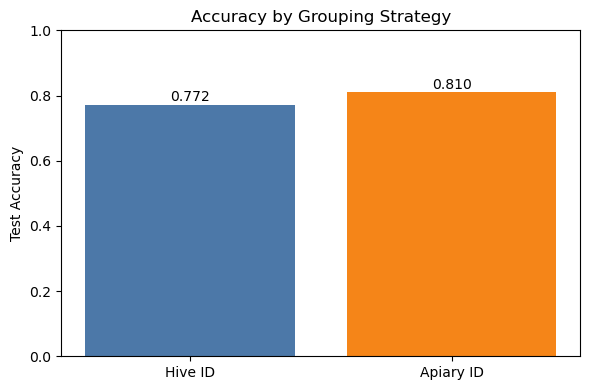


Winner: Apiary ID (group column: ApiaryID) with accuracy=0.810


In [7]:
# Summary: Compare grouping strategies (Hive ID vs Apiary ID)
# Re-runs compact grouped experiments and prints a comparison table
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

# Helpers

def _detect_repo_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]  # type: ignore[name-defined]
    except NameError:
        pass
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / 'data').exists():
            return p
    return cwd

def _pick_group_col(df: pd.DataFrame, keywords: list[str]):
    for c in df.columns:
        lc = str(c).strip().lower()
        if any(k in lc for k in keywords):
            return c
    return None

repo_root = _detect_repo_root()

# Load
candidate_paths = [
    repo_root / 'data' / 'interim' / 'Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'processed' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'interim' / 'final_merged_dataset.csv',
    repo_root / 'final_merged_dataset.csv',
]
df = None
for p in candidate_paths:
    if p.exists():
        try:
            df = pd.read_csv(p)
            print(f"Loaded: {p}")
            break
        except Exception as e:
            print(f"Failed to read {p}: {e}")
if df is None:
    raise FileNotFoundError("final_merged_dataset.csv not found in expected locations.")

# Target
if 'Healthy' not in df.columns:
    raise KeyError("Required column 'Healthy' not found.")
if df['Healthy'].dtype == 'O' or str(df['Healthy'].dtype).startswith('category'):
    df['Healthy'] = df['Healthy'].map({'Yes': 1, 'No': 0})
df['Healthy'] = pd.to_numeric(df['Healthy'], errors='coerce').astype('Int64')

# Features
num_features = [
    'Days_Since_Last_Inspection','Hive_Age_Days',
    'Avg_prcp','Avg_wind','Avg_tmax','Avg_tmin','Avg_tavg','Avg_snow','Num_frost_days'
]
cat_features = [
    'Prev_Brood_Status','Prev_Bees_Status','Prev_Queen_Status','Prev_Food_Status',
    'Prev_Stressors_Status','Prev_Space_Status','Prev_Health_Status'
]

present_num = [c for c in num_features if c in df.columns]
present_cat = [c for c in cat_features if c in df.columns]


def run_grouped_summary(df: pd.DataFrame, group_keywords: list[str], label: str):
    group_col = _pick_group_col(df, group_keywords)
    if group_col is None:
        raise KeyError(f"Group column not found for {label}; looked for {group_keywords}.")
    use_cols = present_num + present_cat + [group_col, 'Healthy']
    d = df[use_cols].copy()
    for c in present_num:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    for c in present_cat:
        d[c] = d[c].astype(str).fillna('Missing')
    d = d.dropna(subset=present_num + [group_col, 'Healthy'])
    X = d[present_num + present_cat]
    y = d['Healthy'].astype(int)
    groups = d[group_col].astype(str)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr, te = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[tr], X.iloc[te]
    y_train, y_test = y.iloc[tr], y.iloc[te]
    train_groups = groups.iloc[tr]

    preprocess = ColumnTransformer([
        ('num', 'passthrough', present_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), present_cat)
    ])

    log_pipe = Pipeline([
        ('prep', preprocess),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42))
    ])
    log_grid = {'clf__C': [0.1, 1.0, 3.0], 'clf__penalty': ['l2']}

    rf_pipe = Pipeline([
        ('prep', preprocess),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ])
    rf_grid = {'clf__max_depth': [None, 8], 'clf__min_samples_leaf': [1, 5], 'clf__max_features': ['sqrt']}

    cv = GroupKFold(n_splits=5)

    log_gs = GridSearchCV(log_pipe, log_grid, scoring='accuracy', cv=cv, n_jobs=-1)
    log_gs.fit(X_train, y_train, groups=train_groups)

    rf_gs = GridSearchCV(rf_pipe, rf_grid, scoring='accuracy', cv=cv, n_jobs=-1)
    rf_gs.fit(X_train, y_train, groups=train_groups)

    # Evaluate both on test
    def metrics(model):
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        roc = None
        ap = None
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
            try:
                roc = roc_auc_score(y_test, y_prob)
                ap = average_precision_score(y_test, y_prob)
            except Exception:
                pass
        return acc, roc, ap

    log_acc, log_roc, log_ap = metrics(log_gs.best_estimator_)
    rf_acc, rf_roc, rf_ap = metrics(rf_gs.best_estimator_)

    if rf_acc >= log_acc:
        best_name = 'RandomForest'
        best_acc, best_roc, best_ap = rf_acc, rf_roc, rf_ap
        best_cv = rf_gs.best_score_
        best_params = rf_gs.best_params_
    else:
        best_name = 'Logistic'
        best_acc, best_roc, best_ap = log_acc, log_roc, log_ap
        best_cv = log_gs.best_score_
        best_params = log_gs.best_params_

    return {
        'Grouping': label,
        'Group_Column': group_col,
        'Train_Size': len(X_train),
        'Test_Size': len(X_test),
        'Best_Model': best_name,
        'Best_Test_Accuracy': best_acc,
        'Best_Test_ROC_AUC': best_roc,
        'Best_Test_AP': best_ap,
        'Best_CV_Accuracy': best_cv,
        'Best_Params': best_params,
    }

hive_res = run_grouped_summary(df, ['hive_id', 'hiveid', 'hive id', 'hive'], 'Hive ID')
apiary_res = run_grouped_summary(df, ['apiary_id', 'apiaryid', 'apiary id', 'apiary'], 'Apiary ID')

summary_df = pd.DataFrame([hive_res, apiary_res])
summary_df = summary_df[['Grouping','Group_Column','Train_Size','Test_Size','Best_Model','Best_CV_Accuracy','Best_Test_Accuracy','Best_Test_ROC_AUC','Best_Test_AP','Best_Params']]
print("\n=== Grouping Summary ===")
print(summary_df.to_string(index=False))

# Simple accuracy bar plot
plt.figure(figsize=(6,4))
plt.bar(summary_df['Grouping'], summary_df['Best_Test_Accuracy'], color=['#4c78a8','#f58518'])
plt.ylim(0,1)
plt.ylabel('Test Accuracy')
plt.title('Accuracy by Grouping Strategy')
for i, v in enumerate(summary_df['Best_Test_Accuracy']):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center')
plt.tight_layout(); plt.show()

winner_idx = summary_df['Best_Test_Accuracy'].idxmax()
print(f"\nWinner: {summary_df.loc[winner_idx,'Grouping']} (group column: {summary_df.loc[winner_idx,'Group_Column']}) with accuracy={summary_df.loc[winner_idx,'Best_Test_Accuracy']:.3f}")

Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/interim/Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data/final_merged_dataset.csv


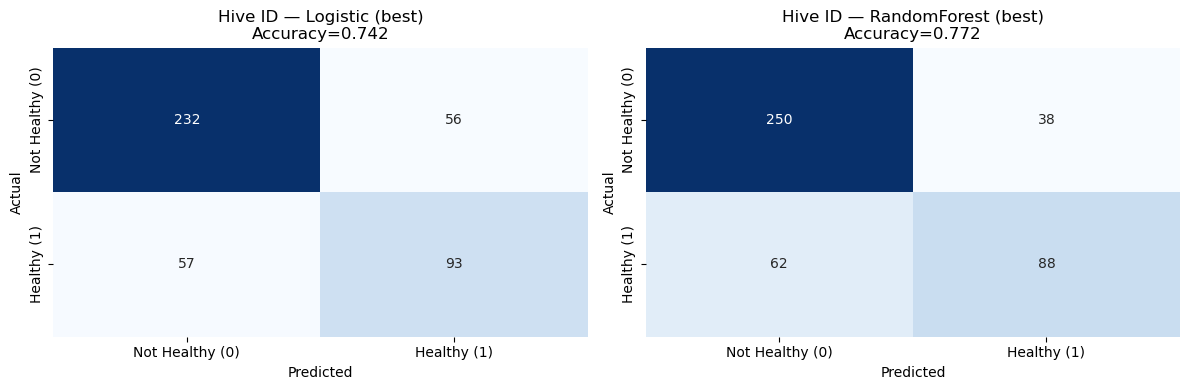

Winner (Hive ID): RandomForest — acc=0.772


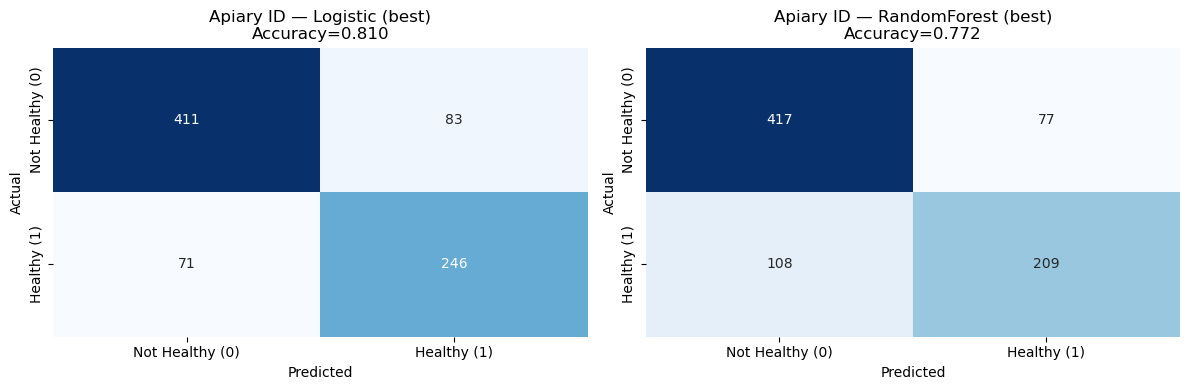

Winner (Apiary ID): Logistic — acc=0.810


In [8]:
# Confusion matrices for grouped models (Hive ID and Apiary ID)
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Helpers

def _detect_repo_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]  # type: ignore[name-defined]
    except NameError:
        pass
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / 'data').exists():
            return p
    return cwd

def _pick_group_col(df: pd.DataFrame, keywords: list[str]):
    for c in df.columns:
        lc = str(c).strip().lower()
        if any(k in lc for k in keywords):
            return c
    return None

repo_root = _detect_repo_root()

# Load dataset
candidate_paths = [
    repo_root / 'data' / 'interim' / 'Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'processed' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'interim' / 'final_merged_dataset.csv',
    repo_root / 'final_merged_dataset.csv',
]
df = None
for p in candidate_paths:
    if p.exists():
        try:
            df = pd.read_csv(p)
            print(f"Loaded: {p}")
            break
        except Exception as e:
            print(f"Failed to read {p}: {e}")
if df is None:
    raise FileNotFoundError("final_merged_dataset.csv not found in expected locations.")

# Target
if 'Healthy' not in df.columns:
    raise KeyError("Required column 'Healthy' not found.")
if df['Healthy'].dtype == 'O' or str(df['Healthy'].dtype).startswith('category'):
    df['Healthy'] = df['Healthy'].map({'Yes': 1, 'No': 0})
df['Healthy'] = pd.to_numeric(df['Healthy'], errors='coerce').astype('Int64')

# Features
num_features = [
    'Days_Since_Last_Inspection','Hive_Age_Days',
    'Avg_prcp','Avg_wind','Avg_tmax','Avg_tmin','Avg_tavg','Avg_snow','Num_frost_days'
]
cat_features = [
    'Prev_Brood_Status','Prev_Bees_Status','Prev_Queen_Status','Prev_Food_Status',
    'Prev_Stressors_Status','Prev_Space_Status','Prev_Health_Status'
]

present_num = [c for c in num_features if c in df.columns]
present_cat = [c for c in cat_features if c in df.columns]


def train_and_confmat(df: pd.DataFrame, group_keywords: list[str], label: str):
    group_col = _pick_group_col(df, group_keywords)
    if group_col is None:
        raise KeyError(f"Group column not found for {label}; looked for {group_keywords}.")

    use_cols = present_num + present_cat + [group_col, 'Healthy']
    d = df[use_cols].copy()
    for c in present_num:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    for c in present_cat:
        d[c] = d[c].astype(str).fillna('Missing')
    d = d.dropna(subset=present_num + [group_col, 'Healthy'])

    X = d[present_num + present_cat]
    y = d['Healthy'].astype(int)
    groups = d[group_col].astype(str)

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr, te = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[tr], X.iloc[te]
    y_train, y_test = y.iloc[tr], y.iloc[te]
    train_groups = groups.iloc[tr]

    preprocess = ColumnTransformer([
        ('num', 'passthrough', present_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), present_cat)
    ])

    log_pipe = Pipeline([
        ('prep', preprocess),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42))
    ])
    log_grid = {'clf__C': [0.1, 1.0, 3.0], 'clf__penalty': ['l2']}

    rf_pipe = Pipeline([
        ('prep', preprocess),
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
    ])
    rf_grid = {'clf__max_depth': [None, 8], 'clf__min_samples_leaf': [1, 5], 'clf__max_features': ['sqrt']}

    cv = GroupKFold(n_splits=5)

    log_gs = GridSearchCV(log_pipe, log_grid, scoring='accuracy', cv=cv, n_jobs=-1)
    log_gs.fit(X_train, y_train, groups=train_groups)
    rf_gs = GridSearchCV(rf_pipe, rf_grid, scoring='accuracy', cv=cv, n_jobs=-1)
    rf_gs.fit(X_train, y_train, groups=train_groups)

    def conf(ax, model, name):
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred, labels=[0,1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                    xticklabels=['Not Healthy (0)','Healthy (1)'],
                    yticklabels=['Not Healthy (0)','Healthy (1)'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(f'{label} — {name}\nAccuracy={acc:.3f}')
        return acc

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    acc_l = conf(axes[0], log_gs.best_estimator_, 'Logistic (best)')
    acc_r = conf(axes[1], rf_gs.best_estimator_, 'RandomForest (best)')
    plt.tight_layout(); plt.show()

    winner = 'RandomForest' if acc_r >= acc_l else 'Logistic'
    print(f"Winner ({label}): {winner} — acc={max(acc_l, acc_r):.3f}")

# Run for both groupings
train_and_confmat(df, ['hive_id','hiveid','hive id','hive'], 'Hive ID')
train_and_confmat(df, ['apiary_id','apiaryid','apiary id','apiary'], 'Apiary ID')

Loaded: /Users/dharineeshsomisetty/fall-2025-bee-health-early-warning-system/data/interim/Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data/final_merged_dataset.csv


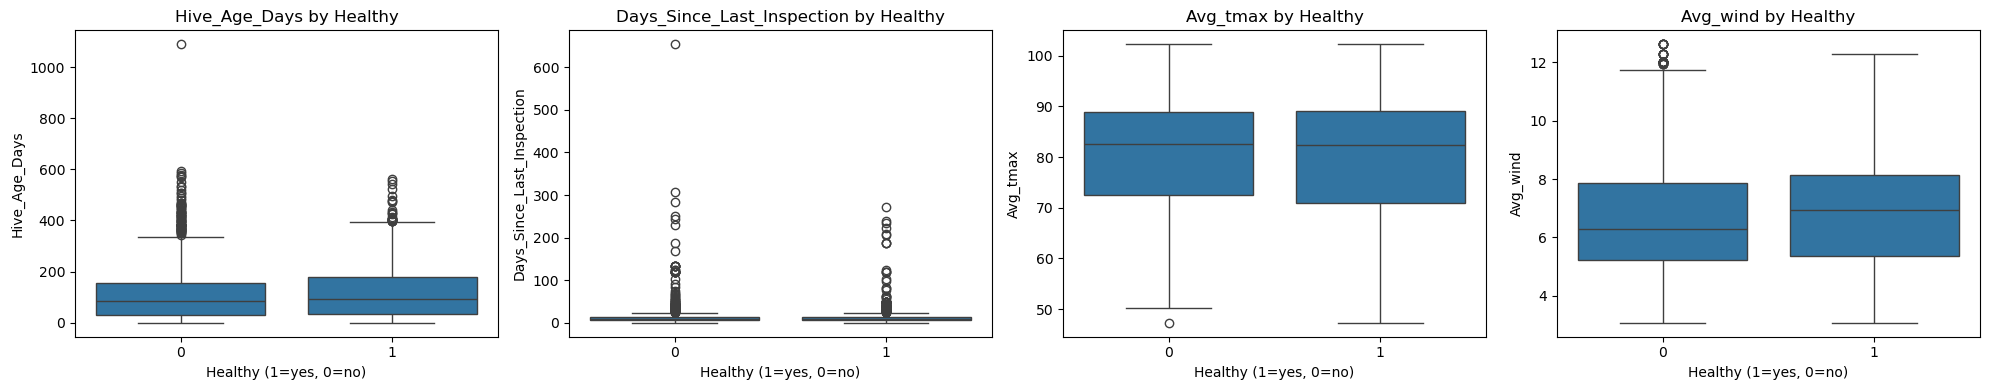

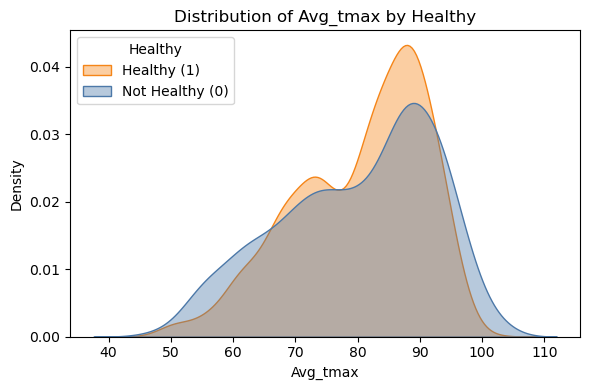

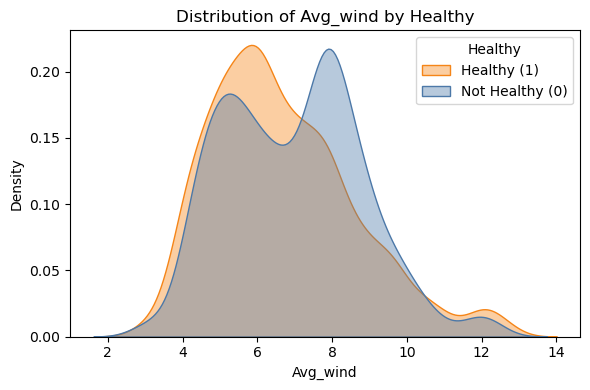

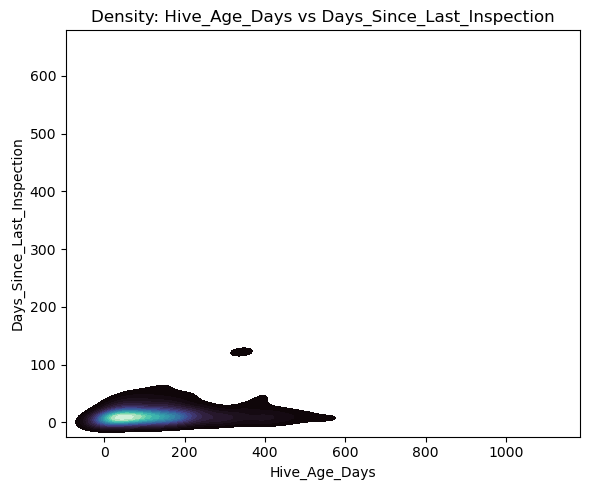

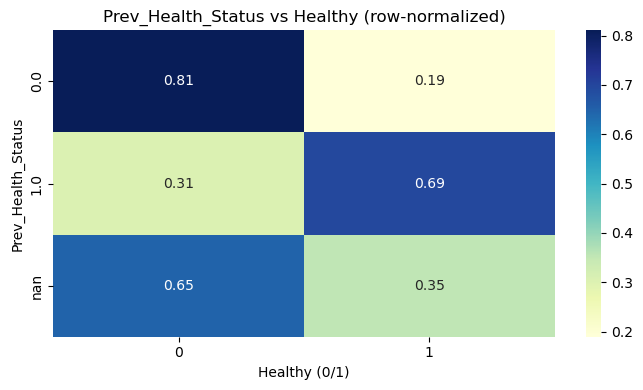

In [2]:
# Extra EDA: deeper feature-target patterns
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (same logic as above)
def _detect_repo_root() -> Path:
    try:
        return Path(__file__).resolve().parents[1]  # type: ignore[name-defined]
    except NameError:
        pass
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / 'data').exists():
            return p
    return cwd

repo_root = _detect_repo_root()
candidate_paths = [
    repo_root / 'data' / 'interim' / 'Predicting Honeybee Health The Healthy Colony Checklist,Hive Scale and Weather Data' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'processed' / 'final_merged_dataset.csv',
    repo_root / 'data' / 'interim' / 'final_merged_dataset.csv',
    repo_root / 'final_merged_dataset.csv',
]
df = None
for p in candidate_paths:
    if p.exists():
        try:
            df = pd.read_csv(p)
            print(f"Loaded: {p}")
            break
        except Exception as e:
            print(f"Failed to read {p}: {e}")
if df is None:
    raise FileNotFoundError("final_merged_dataset.csv not found in expected locations.")

# Target to 0/1
if 'Healthy' not in df.columns:
    raise KeyError("Required column 'Healthy' not found.")
if df['Healthy'].dtype == 'O' or str(df['Healthy'].dtype).startswith('category'):
    df['Healthy'] = df['Healthy'].map({'Yes': 1, 'No': 0})
df['Healthy'] = pd.to_numeric(df['Healthy'], errors='coerce').astype('Int64')

# Choose features if present
num_feats = ['Hive_Age_Days','Days_Since_Last_Inspection','Avg_tmax','Avg_wind']
num_feats = [c for c in num_feats if c in df.columns]
cat_feat = 'Prev_Health_Status' if 'Prev_Health_Status' in df.columns else None

# 1) Boxplots: numeric features vs target
if num_feats:
    n = len(num_feats)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, num_feats):
        sns.boxplot(x=df['Healthy'], y=pd.to_numeric(df[col], errors='coerce'), ax=ax)
        ax.set_xlabel('Healthy (1=yes, 0=no)')
        ax.set_ylabel(col)
        ax.set_title(f'{col} by Healthy')
    plt.tight_layout(); plt.show()
else:
    print('No numeric features available for boxplots.')

# 2) KDEs: distributions split by Healthy
kde_feats = [c for c in ['Avg_tmax','Avg_wind'] if c in num_feats]
for col in kde_feats:
    plt.figure(figsize=(6,4))
    df_kde = df.copy()
    df_kde[col] = pd.to_numeric(df_kde[col], errors='coerce')
    sns.kdeplot(
        data=df_kde.dropna(subset=[col, 'Healthy']),
        x=col,
        hue='Healthy',
        hue_order=[1, 0],
        fill=True,
        common_norm=False,
        alpha=0.4,
        palette={1: '#4c78a8', 0: '#f58518'},
    )
    plt.title(f'Distribution of {col} by Healthy')
    plt.xlabel(col)
    plt.legend(title='Healthy', labels=['Healthy (1)', 'Not Healthy (0)'])
    plt.tight_layout(); plt.show()

# 3) Bivariate heatmap: Hive_Age_Days vs Days_Since_Last_Inspection
if {'Hive_Age_Days','Days_Since_Last_Inspection'}.issubset(df.columns):
    plt.figure(figsize=(6,5))
    sns.kdeplot(
        x=pd.to_numeric(df['Hive_Age_Days'], errors='coerce'),
        y=pd.to_numeric(df['Days_Since_Last_Inspection'], errors='coerce'),
        fill=True, thresh=0.05, levels=20, cmap='mako'
    )
    plt.title('Density: Hive_Age_Days vs Days_Since_Last_Inspection')
    plt.xlabel('Hive_Age_Days')
    plt.ylabel('Days_Since_Last_Inspection')
    plt.tight_layout(); plt.show()

# 4) Categorical breakdown: Prev_Health_Status vs Healthy
if cat_feat:
    plt.figure(figsize=(7,4))
    ct = pd.crosstab(df[cat_feat].astype(str), df['Healthy']).apply(lambda r: r/r.sum(), axis=1)
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlGnBu')
    plt.title('Prev_Health_Status vs Healthy (row-normalized)')
    plt.xlabel('Healthy (0/1)'); plt.ylabel('Prev_Health_Status')
    plt.tight_layout(); plt.show()
else:
    print('Prev_Health_Status not found; skipping categorical breakdown.')

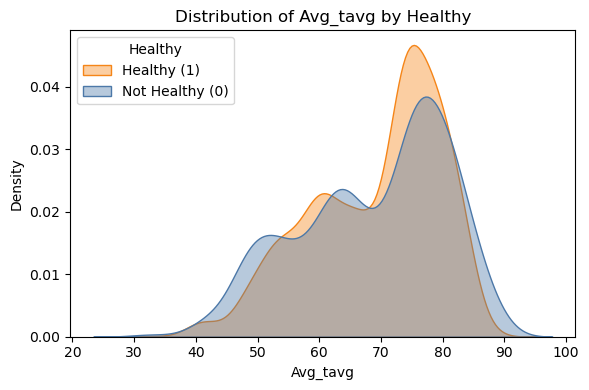

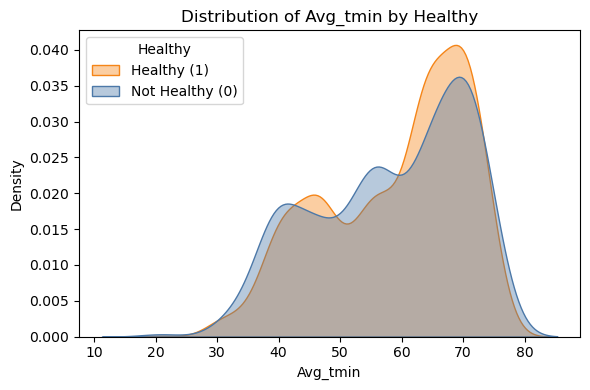

In [4]:
# KDE: Avg_tavg and Avg_tmin by Healthy (cell 8)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Avg_tavg', 'Avg_tmin']

if 'df' in globals() and 'Healthy' in df.columns:
    df_kde = df.copy()
    # Normalize Healthy to 0/1
    if df_kde['Healthy'].dtype == 'O' or str(df_kde['Healthy'].dtype).startswith('category'):
        df_kde['Healthy'] = df_kde['Healthy'].map({'Yes': 1, 'No': 0})
    df_kde['Healthy'] = pd.to_numeric(df_kde['Healthy'], errors='coerce')

    for col in cols:
        if col in df_kde.columns:
            df_kde[col] = pd.to_numeric(df_kde[col], errors='coerce')
            d = df_kde.dropna(subset=[col, 'Healthy'])
            if d.empty:
                print(f"Skipping {col}: no valid rows after cleaning.")
                continue

            plt.figure(figsize=(6,4))
            sns.kdeplot(
                data=d,
                x=col,
                hue='Healthy',
                hue_order=[1, 0],
                fill=True,
                common_norm=False,
                alpha=0.4,
                palette={1: '#4c78a8', 0: '#f58518'},
            )
            plt.title(f'Distribution of {col} by Healthy')
            plt.xlabel(col)
            plt.legend(title='Healthy', labels=['Healthy (1)', 'Not Healthy (0)'])
            plt.tight_layout(); plt.show()
        else:
            print(f"Column '{col}' not found; skipping.")
else:
    print("Dataframe 'df' with 'Healthy' not available; run the data-loading cell first.")